# ⚡ Módulo 10: Support Vector Machines (SVM)

## Objetivos de Aprendizagem

Ao final deste módulo você será capaz de:

- Compreender o conceito de **margem máxima** e **hiperplano de separação**
- Distinguir **Hard Margin** (caso separável) de **Soft Margin** (caso não-separável, parâmetro C)
- Entender e aplicar o **Truque do Kernel** (linear, polinomial, RBF, sigmoid)
- Realizar **tuning de hiperparâmetros** (C e γ) com Grid Search
- Aplicar **One-Class SVM** para detecção de anomalias
- Identificar os **vetores de suporte** e seu papel na solução
- Saber **quando usar SVM** vs outros classificadores

## Teoria Matemática

### Hiperplano de Separação
$$\mathbf{w}^T \mathbf{x} + b = 0$$

### Margem Máxima (caso linearmente separável)
$$\text{Margem} = \frac{2}{||\mathbf{w}||} \quad \text{(maximizar margem)}$$
$$\min_{\mathbf{w},b} \frac{1}{2}||\mathbf{w}||^2 \quad \text{s.t.} \quad y_i(\mathbf{w}^T\mathbf{x}_i + b) \geq 1$$

### Soft Margin (caso não-separável, parâmetro C)
$$\min_{\mathbf{w},b,\xi} \frac{1}{2}||\mathbf{w}||^2 + C\sum_i \xi_i$$
$$\text{s.t.} \quad y_i(\mathbf{w}^T\mathbf{x}_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

### Kernels (Truque do Kernel)
$$K(\mathbf{x}, \mathbf{x}') = \phi(\mathbf{x})^T\phi(\mathbf{x}')$$
- **Linear:** $K(\mathbf{x}, \mathbf{x}') = \mathbf{x}^T\mathbf{x}'$
- **RBF (Gaussiano):** $K(\mathbf{x}, \mathbf{x}') = \exp(-\gamma||\mathbf{x}-\mathbf{x}'||^2)$
- **Polinomial:** $K(\mathbf{x}, \mathbf{x}') = (\mathbf{x}^T\mathbf{x}' + c)^d$

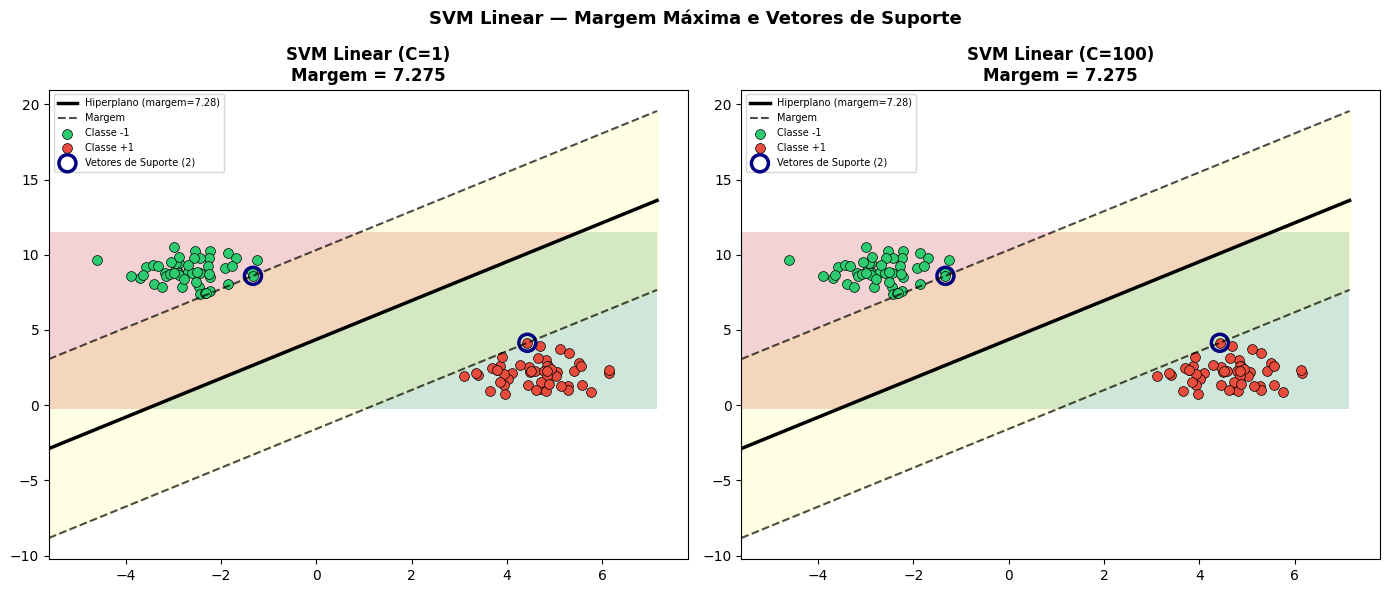

💡 C grande = menos margem, mais casos na margem; C pequeno = mais margem, mais robusto


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC, SVR, OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_classification, make_blobs
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Dataset 2D linearmente separável
X_lin, y_lin = make_blobs(n_samples=100, centers=2, n_features=2, 
                           cluster_std=0.8, random_state=42)
y_lin = 2*y_lin - 1  # classes -1 e +1

svm_lin = SVC(kernel='linear', C=1.0)
svm_lin.fit(X_lin, y_lin)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('SVM Linear — Margem Máxima e Vetores de Suporte', fontsize=13, fontweight='bold')

def plot_svm(ax, svm, X, y, titulo):
    h = 0.02
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='RdYlGn')
    
    # Hiperplano + margens
    if svm.kernel == 'linear':
        w = svm.coef_[0]
        b = svm.intercept_[0]
        x_plot = np.linspace(x_min, x_max, 100)
        y_sep = (-w[0]/w[1])*x_plot - b/w[1]
        y_margin1 = y_sep + 1/w[1]
        y_margin2 = y_sep - 1/w[1]
        ax.plot(x_plot, y_sep, 'k-', lw=2.5, label=f'Hiperplano (margem={2/np.linalg.norm(w):.2f})')
        ax.plot(x_plot, y_margin1, 'k--', lw=1.5, alpha=0.7, label='Margem')
        ax.plot(x_plot, y_margin2, 'k--', lw=1.5, alpha=0.7)
        ax.fill_between(x_plot, y_margin1, y_margin2, alpha=0.1, color='yellow')
    
    ax.scatter(X[y==-1, 0], X[y==-1, 1], c='#2ecc71', s=50, edgecolors='black', lw=0.5, label='Classe -1')
    ax.scatter(X[y==1, 0], X[y==1, 1], c='#e74c3c', s=50, edgecolors='black', lw=0.5, label='Classe +1')
    
    # Vetores de suporte (destacar)
    sv = svm.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=150, facecolors='none', edgecolors='navy', lw=2.5, 
                label=f'Vetores de Suporte ({len(sv)})')
    
    ax.set_title(titulo, fontweight='bold'); ax.legend(fontsize=7)
    return 2/np.linalg.norm(svm.coef_[0]) if svm.kernel == 'linear' else 0

margem = plot_svm(axes[0], svm_lin, X_lin, y_lin, f'SVM Linear (C=1)\nMargem = {2/np.linalg.norm(svm_lin.coef_[0]):.3f}')

# SVM com C grande (menos margem, mais ajustado)
svm_c100 = SVC(kernel='linear', C=100)
svm_c100.fit(X_lin, y_lin)
plot_svm(axes[1], svm_c100, X_lin, y_lin, f'SVM Linear (C=100)\nMargem = {2/np.linalg.norm(svm_c100.coef_[0]):.3f}')

plt.tight_layout()
plt.savefig('../imagens/10_svm_linear.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"💡 C grande = menos margem, mais casos na margem; C pequeno = mais margem, mais robusto")

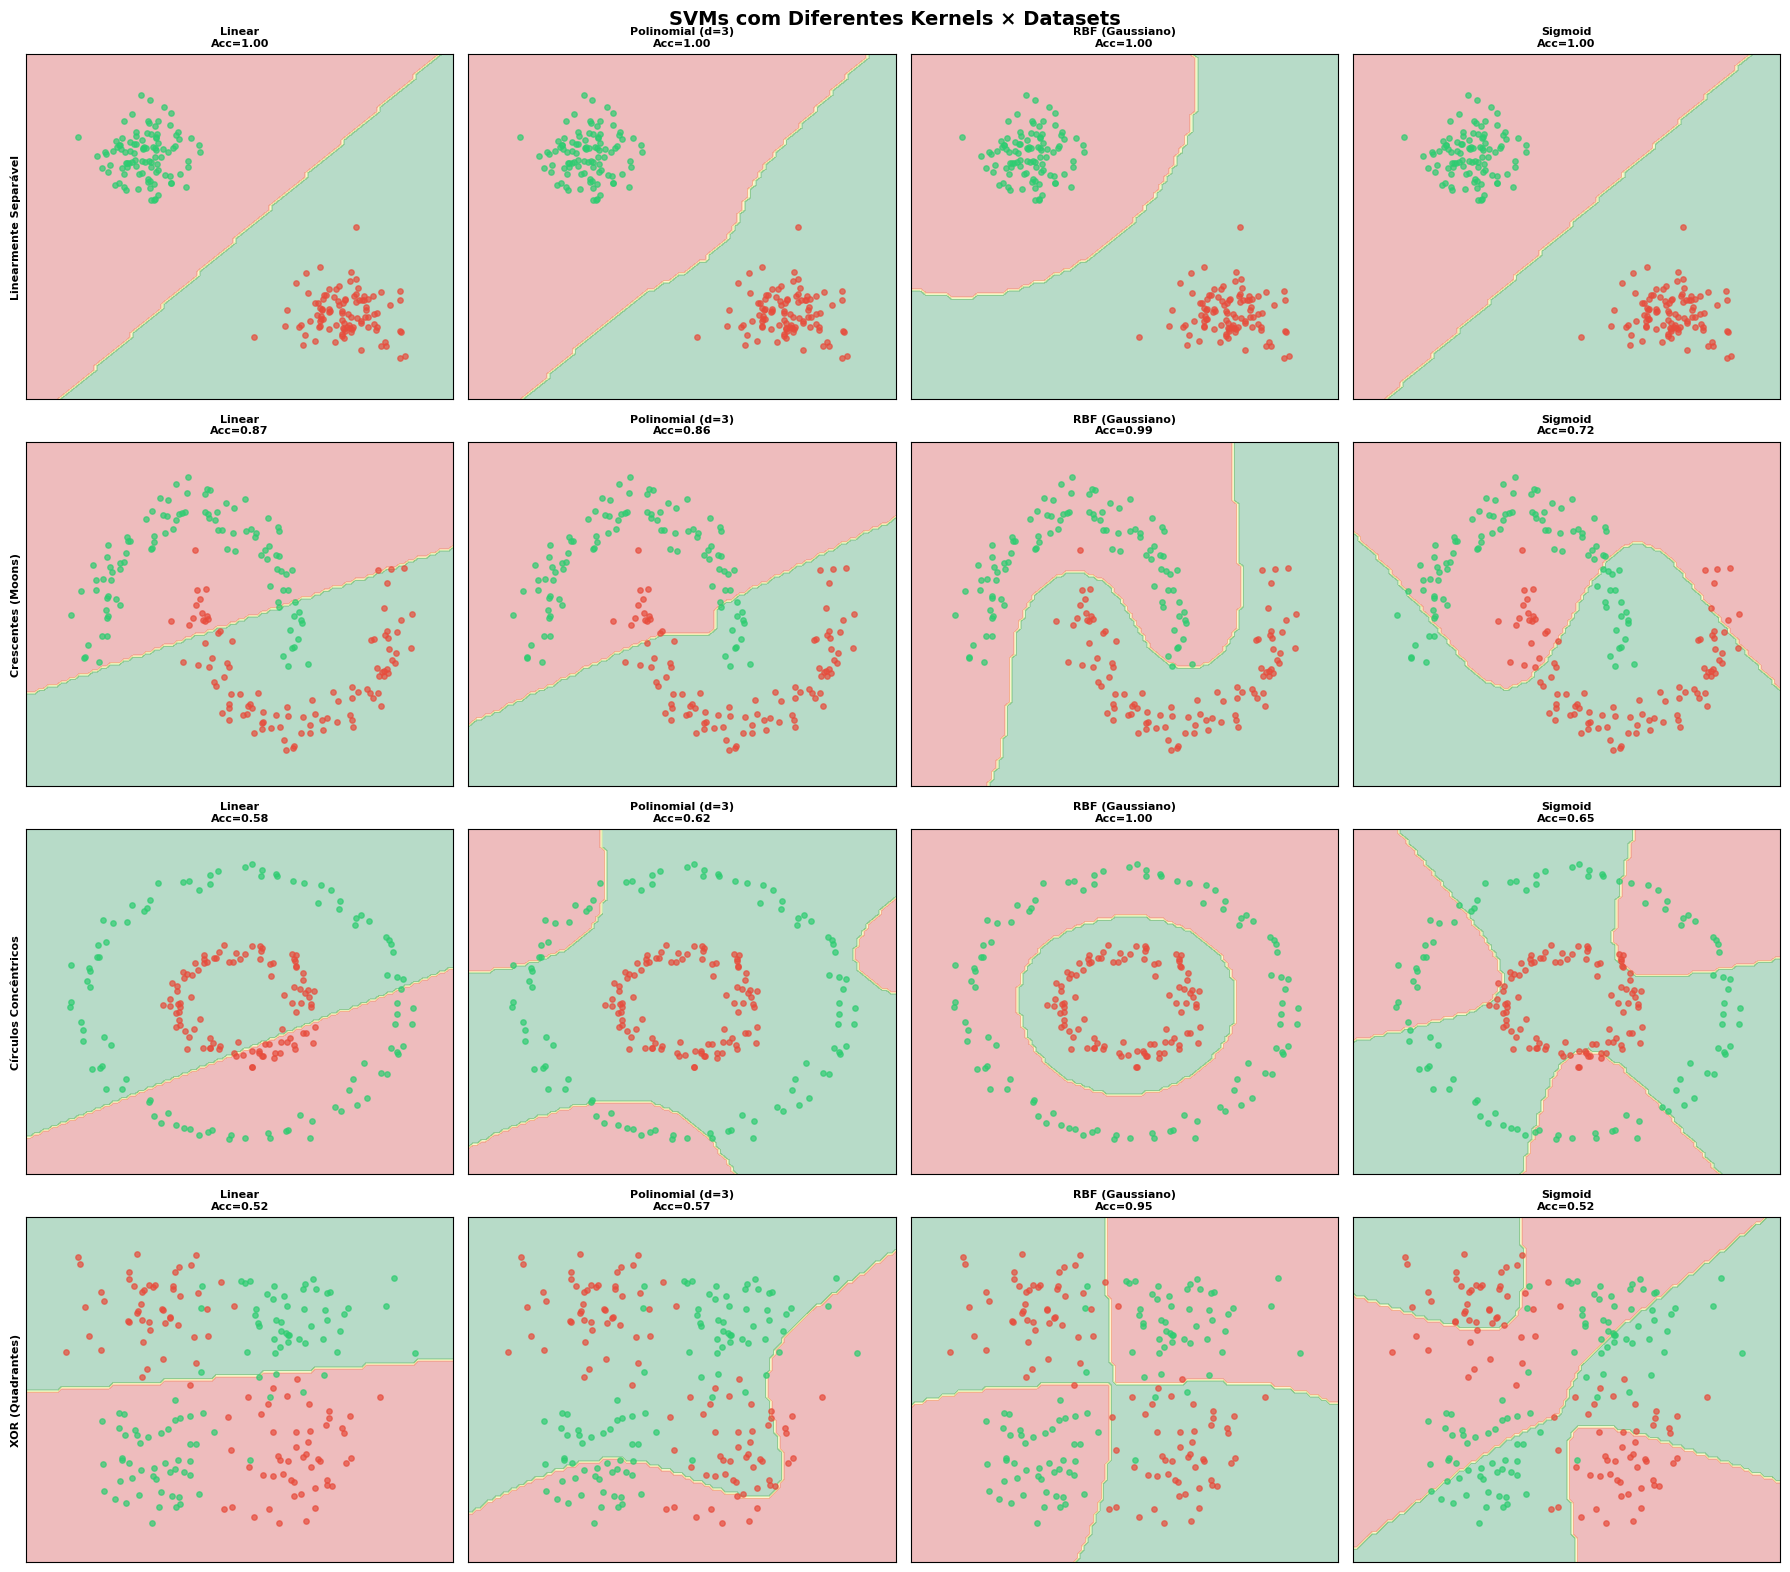

✅ RBF é geralmente o melhor ponto de partida — funciona bem para dados não-lineares


In [2]:
from sklearn.datasets import make_moons, make_circles

# Datasets com formas diferentes
datasets = {
    'Linearmente Separável': make_blobs(n_samples=200, centers=2, cluster_std=1.0, random_state=42),
    'Crescentes (Moons)': make_moons(n_samples=200, noise=0.1, random_state=42),
    'Círculos Concêntricos': make_circles(n_samples=200, noise=0.05, factor=0.4, random_state=42),
    'XOR (Quadrantes)': None,
}
# XOR manual
n_xor = 50
X_xor = np.r_[np.random.randn(n_xor,2)+[2,2], np.random.randn(n_xor,2)+[-2,-2],
               np.random.randn(n_xor,2)+[2,-2], np.random.randn(n_xor,2)+[-2,2]]
y_xor = np.r_[[0]*n_xor, [0]*n_xor, [1]*n_xor, [1]*n_xor]
datasets['XOR (Quadrantes)'] = (X_xor, y_xor)

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
fig.suptitle('SVMs com Diferentes Kernels × Datasets', fontsize=14, fontweight='bold')

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_labels = ['Linear', 'Polinomial (d=3)', 'RBF (Gaussiano)', 'Sigmoid']

for row, (ds_nome, (X_ds, y_ds)) in enumerate(datasets.items()):
    sc = StandardScaler()
    X_ds_sc = sc.fit_transform(X_ds)
    
    for col, (kernel, klabel) in enumerate(zip(kernels, kernel_labels)):
        ax = axes[row, col]
        try:
            svm = SVC(kernel=kernel, C=1.0, gamma='scale', degree=3)
            svm.fit(X_ds_sc, y_ds)
            acc = svm.score(X_ds_sc, y_ds)
            
            h = 0.05
            xmn, xmx = X_ds_sc[:,0].min()-0.5, X_ds_sc[:,0].max()+0.5
            ymn, ymx = X_ds_sc[:,1].min()-0.5, X_ds_sc[:,1].max()+0.5
            xx, yy = np.meshgrid(np.arange(xmn, xmx, h), np.arange(ymn, ymx, h))
            Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
            
            ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
            ax.scatter(X_ds_sc[y_ds==0,0], X_ds_sc[y_ds==0,1], c='#2ecc71', s=15, alpha=0.7)
            ax.scatter(X_ds_sc[y_ds==1,0], X_ds_sc[y_ds==1,1], c='#e74c3c', s=15, alpha=0.7)
            ax.set_title(f'{klabel}\nAcc={acc:.2f}', fontsize=8, fontweight='bold')
        except:
            ax.text(0.5, 0.5, 'Erro', transform=ax.transAxes, ha='center')
        
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(ds_nome, fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('../imagens/10_svm_kernels.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ RBF é geralmente o melhor ponto de partida — funciona bem para dados não-lineares")

🔍 TUNING DO SVM: GRID SEARCH C × γ
Melhores params: {'C': 100, 'gamma': 0.01}
AUC CV:  0.9654
AUC Test: 0.9860

🔍 One-Class SVM — Detecção de Anomalias


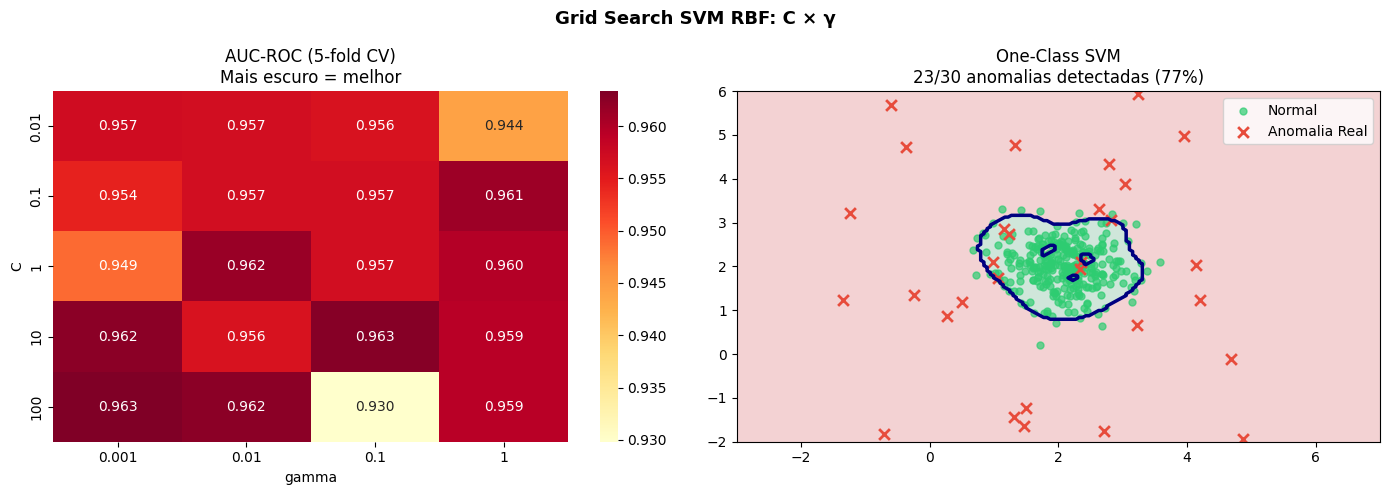

In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV

print("=" * 55)
print("🔍 TUNING DO SVM: GRID SEARCH C × γ")
print("=" * 55)

X_cls, y_cls = make_classification(n_samples=400, n_features=5, n_informative=3, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_cls, y_cls, test_size=0.25, random_state=42)

param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 'scale']}
grid = GridSearchCV(SVC(kernel='rbf', probability=True), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

sc = StandardScaler()
grid.fit(sc.fit_transform(X_tr), y_tr)
print(f"Melhores params: {grid.best_params_}")
print(f"AUC CV:  {grid.best_score_:.4f}")
print(f"AUC Test: {roc_auc_score(y_te, grid.best_estimator_.predict_proba(sc.transform(X_te))[:,1]):.4f}")

# Heatmap do grid search (C vs gamma numérico)
param_gamma_num = [p['gamma'] for p in grid.cv_results_['params'] if p['gamma'] != 'scale']
scores_matrix = grid.cv_results_['mean_test_score'][:20].reshape(5, 4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Grid Search SVM RBF: C × γ', fontsize=13, fontweight='bold')

Cs = [0.01, 0.1, 1, 10, 100]
gammas_num = [0.001, 0.01, 0.1, 1]
sns.heatmap(scores_matrix, xticklabels=gammas_num, yticklabels=Cs, 
            annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0])
axes[0].set_xlabel('gamma'); axes[0].set_ylabel('C')
axes[0].set_title('AUC-ROC (5-fold CV)\nMais escuro = melhor')

# One-Class SVM para detecção de anomalias
print("\n🔍 One-Class SVM — Detecção de Anomalias")
n_norm = 300
X_normal = np.r_[np.random.randn(n_norm, 2) * 0.5 + [2, 2]]
X_anomalia = np.r_[np.random.uniform(-2, 6, (30, 2))]
X_oc = np.vstack([X_normal, X_anomalia])
y_oc = np.r_[[1]*n_norm, [-1]*30]

oc_svm = OneClassSVM(nu=0.1, kernel='rbf', gamma='scale')
oc_svm.fit(X_normal)
preds = oc_svm.predict(X_oc)

xx, yy = np.meshgrid(np.linspace(-3, 7, 200), np.linspace(-2, 6, 200))
Z = oc_svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z, alpha=0.2, cmap='RdYlGn')
axes[1].scatter(X_normal[:,0], X_normal[:,1], c='#2ecc71', s=25, alpha=0.7, label='Normal')
axes[1].scatter(X_anomalia[:,0], X_anomalia[:,1], c='#e74c3c', s=60, marker='x', lw=2, label='Anomalia Real')
axes[1].contour(xx, yy, Z, levels=[0], colors='navy', linewidths=2.5)
n_detectadas = (preds[n_norm:] == -1).sum()
axes[1].set_title(f'One-Class SVM\n{n_detectadas}/30 anomalias detectadas ({n_detectadas/30*100:.0f}%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../imagens/10_svm_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()

## Resumo e Comparação de Kernels

| Kernel | Fronteira | Parâmetros | Quando Usar |
|--------|-----------|------------|-------------|
| **Linear** | Hiperplano reto | C | Dados linearmente separáveis, alta dimensionalidade (texto) |
| **Polinomial** | Curvas suaves de grau d | C, d, coef0 | Dados com interações polinomiais conhecidas |
| **RBF (Gaussiano)** | Fronteiras suaves e circulares | C, γ | Ponto de partida geral; não-linearmente separável |
| **Sigmoid** | Similar a redes neurais | C, γ, coef0 | Raramente melhor que RBF; use com cautela |

### Guia de Seleção de Hiperparâmetros

- **C pequeno** (0.01–1): margem grande, mais regularização, melhor para dados com ruído
- **C grande** (10–1000): margem pequena, ajuste fino ao treino, risco de overfitting
- **γ pequeno**: fronteira suave (influence zone ampla) — underfitting se muito pequeno
- **γ grande**: fronteira irregular (influence zone estreita) — overfitting se muito grande
- **Regra prática**: comece com `gamma='scale'` e faça grid search em C ∈ [0.1, 1, 10, 100]

### Quando Usar SVM

- Datasets de **tamanho médio** (< 100k amostras) — SVM escala O(n²) a O(n³)
- **Alta dimensionalidade** com poucas amostras (texto, genômica)
- Quando a **margem máxima** é importante (classificação robusta)
- **Detecção de anomalias** (One-Class SVM)

## Exercícios Propostos

1. **SVR (Regressão)**: use `sklearn.svm.SVR` com kernel RBF no dataset California Housing. Compare com regressão linear.
2. **Pipeline completo**: crie um Pipeline com StandardScaler + SVC e use GridSearchCV para encontrar os melhores C e gamma.
3. **Curva de validação**: plote a acurácia de treino e validação para diferentes valores de C (de 0.001 a 1000 em escala log).
4. **Análise de vetores de suporte**: compare o número de vetores de suporte para diferentes valores de C. O que você observa?
5. **One-Class SVM**: aplique no dataset KDDCup99 (detecção de intrusão) e compare com Isolation Forest.